In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [3]:
import pandas as pd 
import math
df = pd.DataFrame({ "Programming":["Good","Good","Good","Good","Average","Average","Average","Average","Poor","Poor"], "Experience":["High","Low","High","Low","High","High","Low","Low","High","Low"], "Communication":["Good","Good","Average","Average","Good","Poor","Good","Poor","Average","Poor"], "Hire":["Yes","Yes","Yes","Yes","Yes","Yes","Yes","No","No","No"] })
df

,Programming,Experience,Communication,Hire
0,Good,High,Good,Yes
1,Good,Low,Good,Yes
2,Good,High,Average,Yes
3,Good,Low,Average,Yes
4,Average,High,Good,Yes
5,Average,High,Poor,Yes
6,Average,Low,Good,Yes
7,Average,Low,Poor,No
8,Poor,High,Average,No
9,Poor,Low,Poor,No


Entropy Function

In [5]:
def entropy(labels):
    total=len(labels)
    counts=labels.value_counts()

    e=0

    for c in counts:
        p=c/total
        e-=p*math.log2(p)

    return e

print("Parent Entropy = ",round(entropy(df["Hire"]),4))

Parent Entropy =  0.8813


In [6]:
def information_gain(data,feature,target):
    parent_entropy=entropy(data[target])
    weighted_entropy=0

    for value in data[feature].unique():
        subset=data[data[feature]==value]

        weighted_entropy+=(len(subset)/len(data))*entropy(subset[target])
    
    return parent_entropy-weighted_entropy


In [7]:
features=['Programming',"Experience",'Communication']

for feature in features:
    gain=information_gain(df,feature,"Hire")
    print(f"{feature:15} -> {gain:.4f}")

Programming     -> 0.5568
Experience      -> 0.0349
Communication   -> 0.3303


In [10]:
best_feature=max(features,key=lambda\
                 f:information_gain(df,f,"Hire"))
print("Best feature = ",best_feature)

Best feature =  Programming


In [13]:
def id3(data,target,features,depth=0):
    labels=data[target]

# Base Condition 1
    if len(labels.unique())==1:
        return labels.iloc[0]

# Base Condition 2
    if len(features)==0:
        return labels.mode()[0]

    gains={f:information_gain(data,f,target) for f in features}

    best=max(gains,key=gains.get)

    tree={best:{}}

    remaining=[f for f in features if f!=best]

    for value in data[best].unique():

        subset=data[data[best]==value]

        if subset.empty:
            tree[best][value]=labels.mode()[0]
        else:
            tree[best][value]=id3(
                subset.drop(columns=[best]),
                target,
                remaining,
                depth+1
            )

    return tree
tree=id3(df,"Hire",["Programming","Experience","Communication"])
tree

{'Programming': {'Good': 'Yes',
  'Average': {'Experience': {'High': 'Yes',
    'Low': {'Communication': {'Good': 'Yes', 'Poor': 'No'}}}},
  'Poor': 'No'}}

In [14]:
def predict(tree,sample):
    if not isinstance(tree,dict):
        return tree

    root=list(tree.keys())[0]

    value=sample[root]

    child=tree[root].get(value)

    if child is None:
        return "Unknown"

    return predict(child,sample)

In [22]:
candidate={
    "Programming":'Average',
    "Experience":"High",
    "Communication":"Good"
}

print(candidate)
print("prediction = ",predict(tree,candidate))

{'Programming': 'Average', 'Experience': 'High', 'Communication': 'Good'}
prediction =  Yes


In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


df = pd.DataFrame({
    "Programming": ["Good", "Good", "Good", "Good", "Average", "Average", "Average", "Average", "Poor", "Poor"],
    "Experience": ["High", "Low", "High", "Low", "High", "High", "Low", "Low", "High", "Low"],
    "Communication": ["Good", "Good", "Average", "Average", "Good", "Poor", "Good", "Poor", "Average", "Poor"],
    "Hire": ["Yes", "Yes", "Yes", "Yes", "Yes", "Yes", "Yes", "No", "No", "No"]
})

df['Programming'] = df['Programming'].map({'Poor': 0, 'Average': 1, 'Good': 2})
df['Experience'] = df['Experience'].map({'Low': 0, 'High': 1})
df['Communication'] = df['Communication'].map({'Poor': 0, 'Average': 1, 'Good': 2})
df['Hire'] = df['Hire'].map({'No': 0, 'Yes': 1})


X = df.drop(columns=['Hire'])
y = df['Hire']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = DecisionTreeClassifier(
    criterion="entropy", 
    max_depth=5, 
    random_state=42
)


model.fit(X_train, y_train)


prediction = model.predict(X_test)
print("Accuracy :", accuracy_score(y_test, prediction))


Accuracy : 0.5


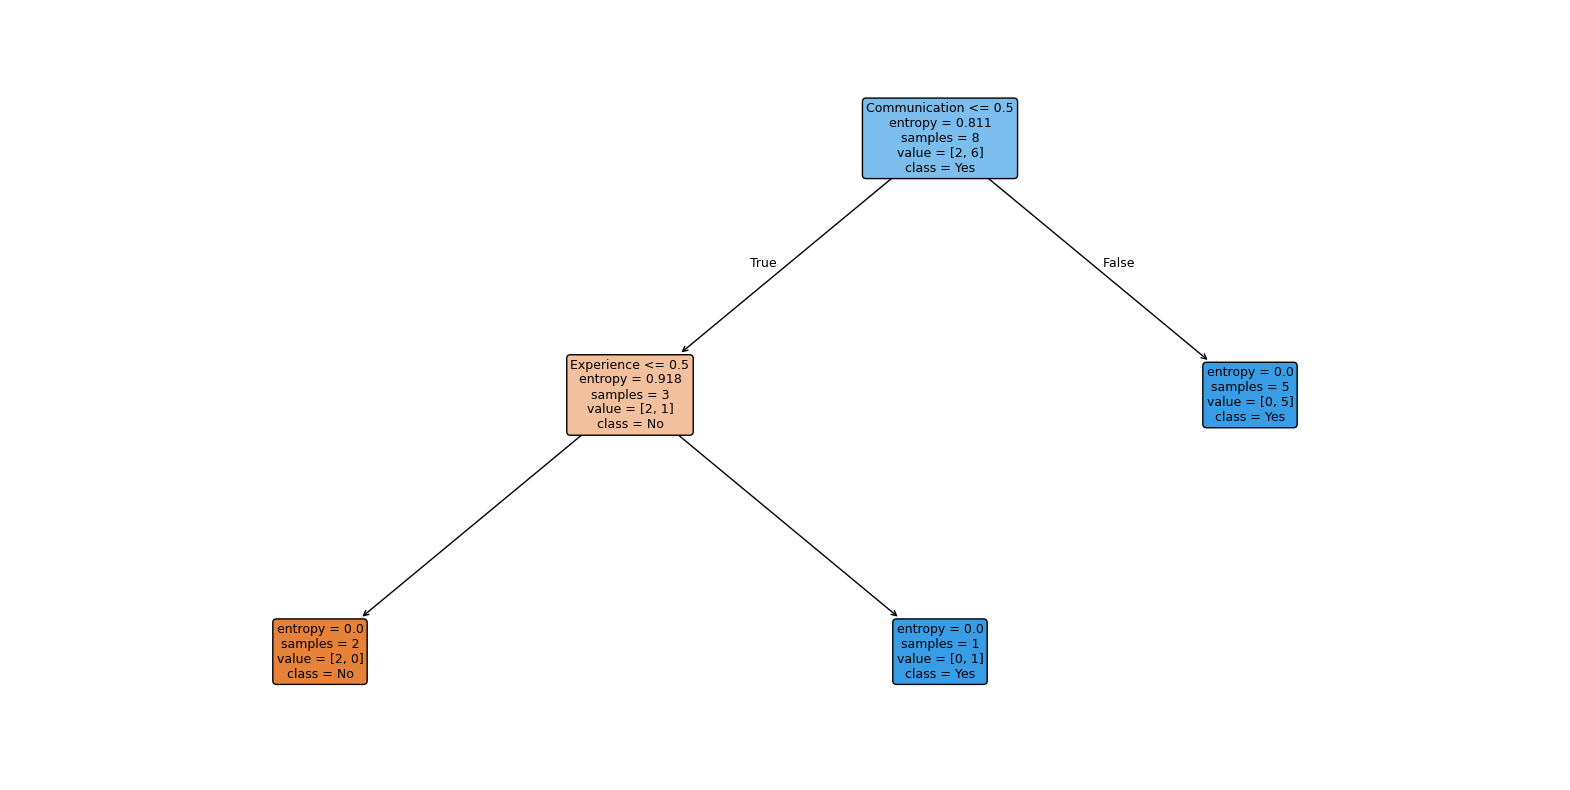

In [24]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No","Yes"],
    filled=True,
    rounded=True,
    fontsize=9
    
)
plt.show()